In [1]:
# ML, DL and vision libraries
import torch
from torch import nn
import torch_optimizer as optim2
from torch.optim import lr_scheduler
from torchvision import transforms
from sklearn import metrics

# Import custom-built libraries
import get_data
import coatnet
import train
import understand

# Import data viz. libraries
import matplotlib.pyplot as plt

# Other basic imports
from os import path

# Import dataset specific libraries
from astroNN.datasets import galaxy10

In [2]:
# Define image augmentation for training data
train_transforms = transforms.Compose([
    transforms.Resize(224), 
    transforms.RandAugment(2, 20),
    transforms.ToTensor()])
image_transforms = {
    "train": train_transforms,
    "val": None,
    "test": None}

# Load the data
root = "data"
if not path.exists(root):
    get_data.generate_and_save_splits(root=root)
data_loaders = get_data.load_data(
    debug=True, 
    image_transforms=image_transforms)

# Define model
args = {
    "image_size": (224, 224),
    "in_channels": 3,
    "num_blocks": [2, 2, 3, 5, 2],
    "channels": [64, 96, 192, 384, 768],
    "num_classes": 10,
    "block_types": ["C", "C", "C", "T"]}
model = coatnet.CoAtNet(
    image_size=args["image_size"],
    in_channels=args["in_channels"],
    num_blocks=args["num_blocks"],
    channels=args["channels"],
    num_classes=args["num_classes"],
    block_types=args["block_types"])

# Define optimizer and loss
radam = optim2.RAdam(model.parameters(), lr=1e-3, weight_decay=1e-2)
lookahead = optim2.Lookahead(radam, k=5, alpha=0.5)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Define sequential scheduler for linear warmup over 10 epochs 
# and cosine decay over 90 epochs
lr_lambda = lambda epoch: (epoch + 1) / 5
warmup_scheduler = lr_scheduler.LambdaLR(lookahead, lr_lambda=lr_lambda)
decay_scheduler = lr_scheduler.CosineAnnealingLR(
    lookahead, 
    T_max=295, 
    eta_min=2e-5)
scheduler = lr_scheduler.SequentialLR(
    lookahead, 
    schedulers=[warmup_scheduler, decay_scheduler], 
    milestones=[5])

# Train model
n_epochs = 300
history = train.train(
    model=model, 
    data_loaders=data_loaders, 
    n_epochs=n_epochs,
    loss_fn=loss_fn,
    optimizer=lookahead,
    scheduler=scheduler,
    gradient_clip=None,
    batch_size=16)

c:\Users\nikhi\anaconda3\envs\galaxy10-cli\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3596.)


Epoch [1/300]: Train Loss = 2.4632; Train Acc. = 0.1562
Epoch [1/300]: Val Loss = 2.3300; Val Acc. = 0.0938

Epoch [2/300]: Train Loss = 2.4396; Train Acc. = 0.1250
Epoch [2/300]: Val Loss = 2.3209; Val Acc. = 0.0312

Epoch [3/300]: Train Loss = 2.2923; Train Acc. = 0.1562
Epoch [3/300]: Val Loss = 2.3165; Val Acc. = 0.0938

Epoch [4/300]: Train Loss = 2.2460; Train Acc. = 0.2188
Epoch [4/300]: Val Loss = 2.3039; Val Acc. = 0.0938



c:\Users\nikhi\anaconda3\envs\galaxy10-cli\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.


Epoch [5/300]: Train Loss = 2.3468; Train Acc. = 0.1562
Epoch [5/300]: Val Loss = 2.2992; Val Acc. = 0.0938

Epoch [6/300]: Train Loss = 2.2759; Train Acc. = 0.0625
Epoch [6/300]: Val Loss = 2.3026; Val Acc. = 0.0938

Epoch [7/300]: Train Loss = 2.2540; Train Acc. = 0.1875
Epoch [7/300]: Val Loss = 2.3216; Val Acc. = 0.1250

Epoch [8/300]: Train Loss = 2.3432; Train Acc. = 0.1250
Epoch [8/300]: Val Loss = 2.3124; Val Acc. = 0.1250

Epoch [9/300]: Train Loss = 2.1888; Train Acc. = 0.2500
Epoch [9/300]: Val Loss = 2.3419; Val Acc. = 0.0938

Epoch [10/300]: Train Loss = 2.3884; Train Acc. = 0.1875
Epoch [10/300]: Val Loss = 2.3163; Val Acc. = 0.0938

Epoch [11/300]: Train Loss = 2.3046; Train Acc. = 0.0312
Epoch [11/300]: Val Loss = 2.2886; Val Acc. = 0.0938

Epoch [12/300]: Train Loss = 2.1144; Train Acc. = 0.3438
Epoch [12/300]: Val Loss = 2.3286; Val Acc. = 0.1250

Epoch [13/300]: Train Loss = 2.2830; Train Acc. = 0.0312
Epoch [13/300]: Val Loss = 2.3501; Val Acc. = 0.1250

Epoch [14/3

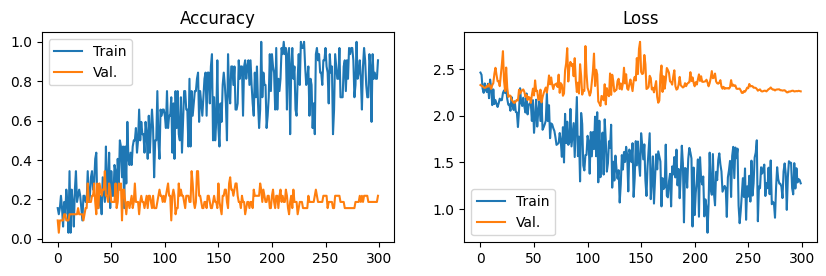

In [3]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(history["train_accuracy"], label="Train")
plt.plot(history["val_accuracy"], label="Val.")
plt.legend()
plt.title("Accuracy")
plt.subplot(2, 2, 2)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val.")
plt.legend()
plt.title("Loss")
plt.show()

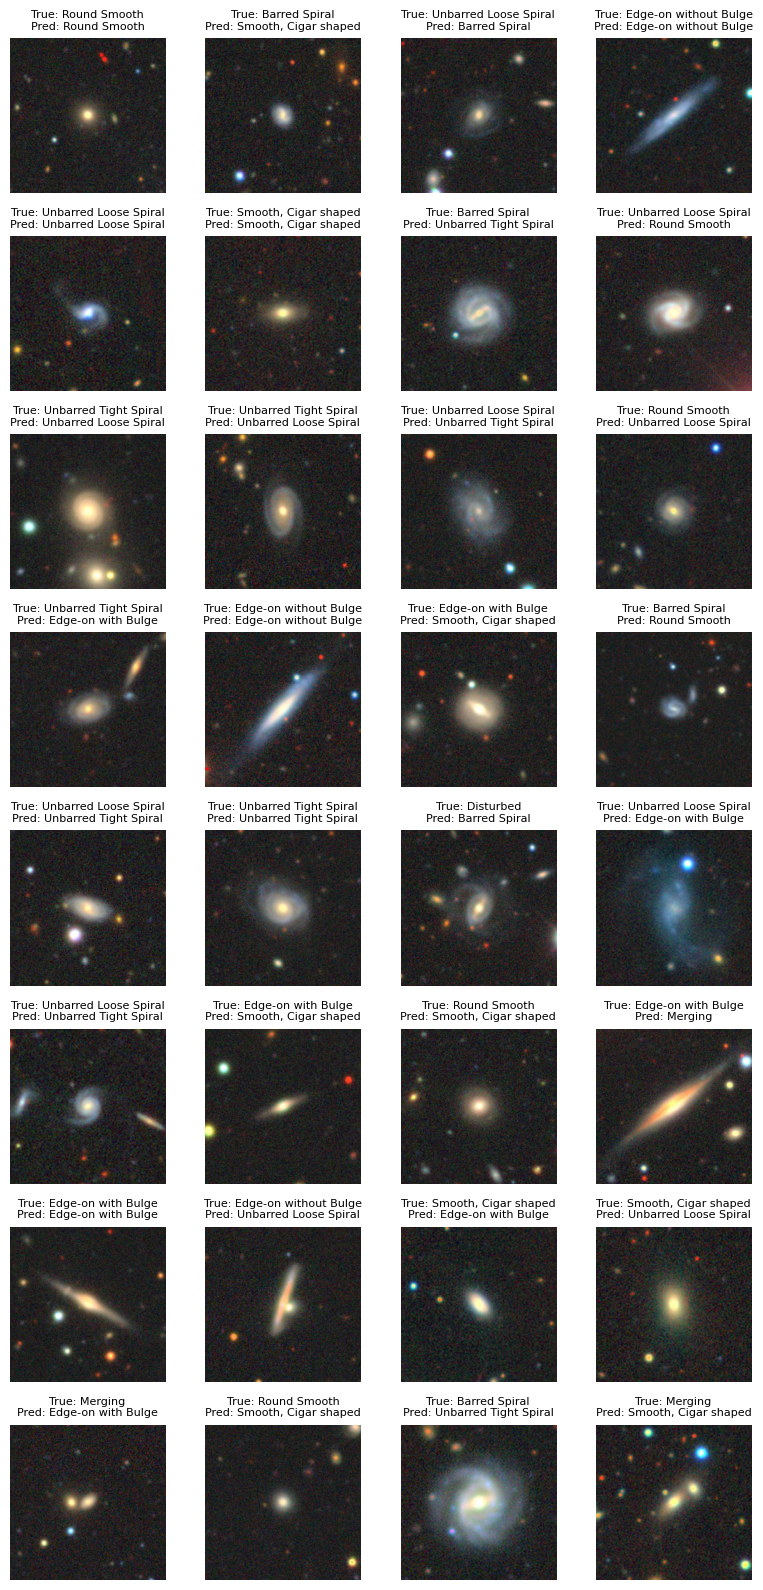

In [4]:
# Inspect results
understand.inspect_predictions(
    model=model, 
    data_loader=data_loaders["val"], 
    batches=2)

In [ ]:
# Visualize results
y_hat, y = train.predict(model, data_loaders["train"])
f1_score = metrics.f1_score(y, y_hat, average="macro")
accuracy_score = metrics.accuracy_score(y, y_hat)
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    y_true=y,
    y_pred=y_hat,
    display_labels=[galaxy10.galaxy10cls_lookup(i) for i in range(10)],
    xticks_rotation="vertical")
plt.title(
    f"F1 Score: {f1_score:.04f}; Accuracy Score: {accuracy_score:.04f}", 
    fontsize=10)
plt.show()

In [ ]:
# Save model state dict
PATH = "saved_models/coatnet.new.4.pt"
torch.save({
    "model_state": model.state_dict(),
    "model_args": args,
    "epoch": n_epochs
    }, PATH)